# 4.3 Final Project Submission

## Smart Color and Shape Detection System

For my final project, I built a Smart Color and Shape Detection System using Python and OpenCV.
The goal of this project is to detect at least three colors and three shapes from images. I will test my system using images stored in a relative folder and display labeled results.

## Setup

Here, I am importing the libraries needed for image processing and visualization.

In [121]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams["figure.figsize"] = (8,8)

## Image Folder (Relative Path)

Here, I am setting up a relative path to my image folder. This makes the notebook portable and easier to run on other systems.

In [124]:
BASE_DIR = Path.cwd()
IMG_DIR = BASE_DIR / "SC_SDS_Images"

print("BASE_DIR:", BASE_DIR)
print("IMG_DIR exists:", IMG_DIR.exists())

BASE_DIR: C:\Users\MasterDanteDev86\Downloads\CAP415-O Computer Vision - Online\W4
IMG_DIR exists: True


## Preview Images in Folder

Here, I will list the images found in the folder. This helps verify that my relative path is correct.

In [127]:
image_files = list(IMG_DIR.glob("*.*"))
image_files = sorted(image_files)

print("Images found:", [img.name for img in image_files])

if len(image_files) == 0:
    raise FileNotFoundError("No images were found in SC_SDS_Images. Please add images and try again.")

Images found: ['Exotic_Cars.jpg', 'Fruit_Bowl.jpeg', 'Guitar_Bodys.jpg', 'Types_of_Flowers.jpeg']


## Load One Image (Quick Check)

Here, I will load one image to confirm that reading and plotting works before running the full pipeline.

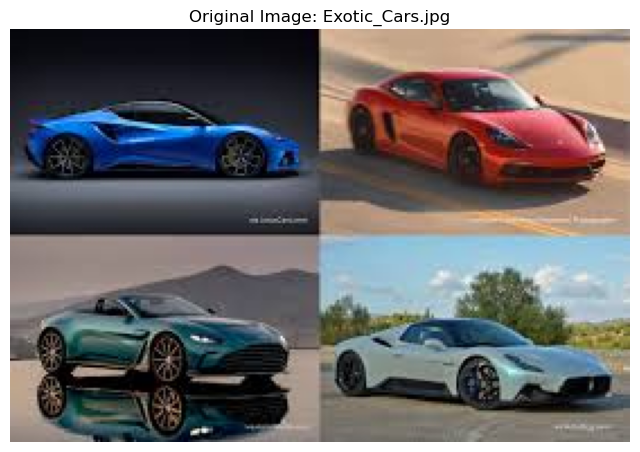

In [130]:
IMG_PATH = image_files[0]

bgr = cv2.imread(str(IMG_PATH))
rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

plt.imshow(rgb)
plt.title(f"Original Image: {IMG_PATH.name}")
plt.axis("off")
plt.show()

## Convert to HSV

HSV color space makes it easier to isolate specific colors.

HSV stands for Hue, Saturation, and Value. In this project, I use HSV instead of RGB because it makes it easier to separate colors from brightness. This helps when trying to detect specific colors like red, green, or blue in different lighting conditions.

In [133]:
hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

## Create Color Masks

Here, I am creating masks for red, green, and blue. These ranges may vary slightly depending on lighting.

A color mask is created by selecting a specific color range and turning those matching pixels white, while everything else becomes black. This allows me to isolate only the parts of the image that match the color I want to detect.

In [136]:
def build_masks(hsv_img):

    # Red (two ranges)
    red1_low  = np.array([0, 80, 80])
    red1_high = np.array([10, 255, 255])
    red2_low  = np.array([170, 80, 80])
    red2_high = np.array([180, 255, 255])

    mask_red = cv2.bitwise_or(
        cv2.inRange(hsv_img, red1_low, red1_high),
        cv2.inRange(hsv_img, red2_low, red2_high)
    )

    # Green
    green_low  = np.array([35, 80, 80])
    green_high = np.array([85, 255, 255])
    mask_green = cv2.inRange(hsv_img, green_low, green_high)

    # Blue
    blue_low  = np.array([95, 80, 80])
    blue_high = np.array([130, 255, 255])
    mask_blue = cv2.inRange(hsv_img, blue_low, blue_high)

    return {"red": mask_red, "green": mask_green, "blue": mask_blue}

masks = build_masks(hsv)
print("Masks created:", list(masks.keys()))

Masks created: ['red', 'green', 'blue']


## Clean Masks

Here I apply morphological operations to reduce noise and improve contour detection.

Sometimes after creating a mask, there are small white spots that are not part of the real object. Cleaning the mask removes this noise so the detection process becomes more accurate.

Morphological operations are image processing steps used to improve binary images. In this project, I used opening and closing operations to remove small noise and fill small gaps, which helps improve contour detection.

Contour detection is used to find the outlines of objects in the mask. Once the colored areas are isolated, contour detection allows me to detect the boundaries and determine what shape the object is.

In [139]:
def clean_mask(mask):
    kernel = np.ones((5,5), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel)
    return mask

for k in masks:
    masks[k] = clean_mask(masks[k])

## Shape Classification

Here, I classify shapes based on contour approximation.

In [142]:
def classify_shape(contour):
    peri = cv2.arcLength(contour, True)
    approx = cv2.approxPolyDP(contour, 0.04 * peri, True)

    sides = len(approx)

    if sides == 3:
        return "triangle"
    elif sides == 4:
        return "rectangle"
    elif sides > 4:
        return "circle"
    else:
        return "unknown"

## Detect and Draw Results (All Images)

Now I will loop through all images in my folder, detect colors and shapes, and draw bounding boxes with labels.

Processing: Exotic_Cars.jpg


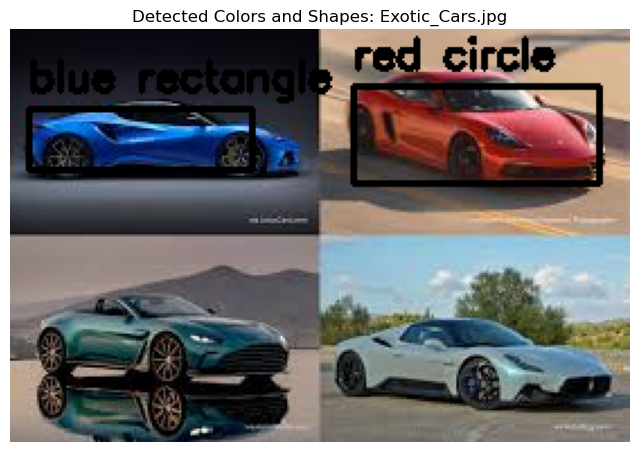

Processing: Fruit_Bowl.jpeg


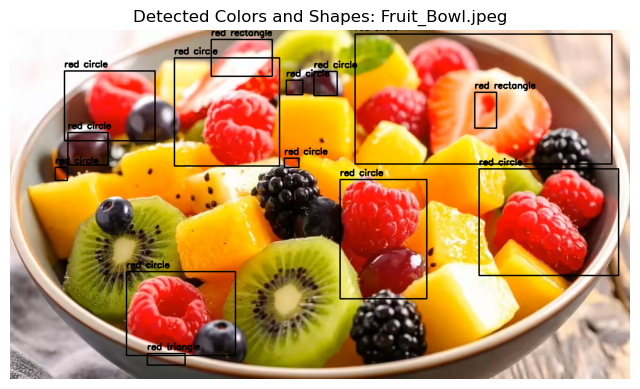

Processing: Guitar_Bodys.jpg


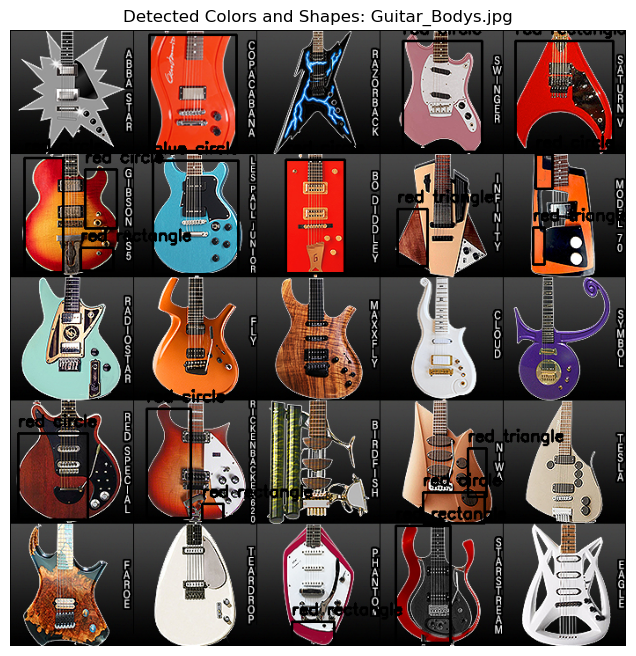

Processing: Types_of_Flowers.jpeg


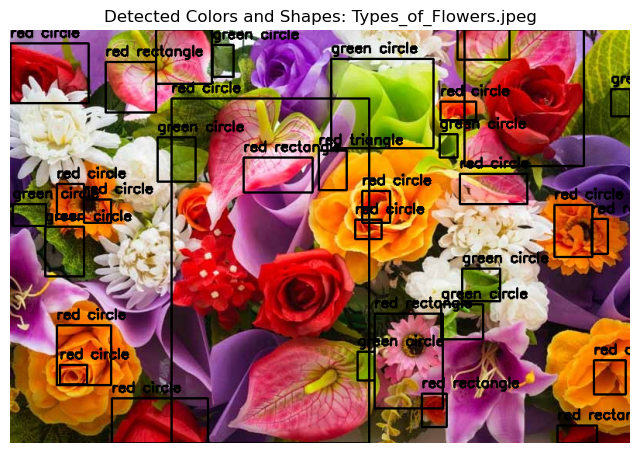

In [145]:
MIN_AREA = 300

for img_path in image_files:

    print("Processing:", img_path.name)

    bgr = cv2.imread(str(img_path))
    if bgr is None:
        print("Skipping (could not read):", img_path.name)
        continue

    hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)

    masks = build_masks(hsv)
    for k in masks:
        masks[k] = clean_mask(masks[k])

    output = bgr.copy()

    for color_name, mask in masks.items():
        contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

        for cnt in contours:
            area = cv2.contourArea(cnt)
            if area < MIN_AREA:
                continue

            shape_name = classify_shape(cnt)

            x, y, w, h = cv2.boundingRect(cnt)
            cv2.rectangle(output, (x,y), (x+w,y+h), (0,0,0), 2)

            label = f"{color_name} {shape_name}"
            cv2.putText(output, label, (x, y-8),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0,0,0), 2)

    out_rgb = cv2.cvtColor(output, cv2.COLOR_BGR2RGB)
    plt.imshow(out_rgb)
    plt.title(f"Detected Colors and Shapes: {img_path.name}")
    plt.axis("off")
    plt.show()

## Reflection

The HSV masking worked well for detecting stronger colors in my images. I noticed lighting plays a big role, and if an image is darker, the color ranges sometimes needed small adjustments to improve detection. For example, in the Exotic_Cars image, red and blue were detected clearly, but some darker areas were harder to isolate at first.

Cleaning the masks helped reduce noise and made contour detection more stable. Without the morphological operations, I was getting small unwanted contours that affected the shape classification.

Testing multiple images helped confirm that the detection pipeline works across different scenes and not just one example. Breaking the notebook into smaller sections made debugging easier, because I could isolate whether the issue was coming from the color masks, contour detection, or shape classification.

If I had more time, I would experiment with adaptive thresholds and possibly test the system using live webcam input to see how it performs in real time environments with changing lighting conditions.